# Эконометрический анализ факторов заработной платы с помощью Python  

# Часть 1. Исследовательский анализ данных о заработной плате

## 1. Формирование и подготовка выборки

В выборке буду брать
- мужчин 18–55 лет
- проживающих в Орске, Оренбургской области
- участвовавших в опросе RLMS в 2024 году

In [3]:
import pandas as pd
import numpy as np

df = pd.read_stata("r33i_os_84.dta", convert_categoricals=False)

# заменяем служебные пропуски RLMS на NaN
df = df.replace({
    99999995: np.nan, 99999996: np.nan, 99999997: np.nan,
    99999998: np.nan, 99999999: np.nan
})

# фильтры варианта: год, регион, пол, возраст
df = df[
    (df["cc_int_y"] == 2024) &
    (df["region"] == 47) &
    (df["cch5"] == 1) &
    (df["cc_age"] >= 18) &
    (df["cc_age"] <= 55) &
    (df["cc_adult"] == 1)
]

# зарплата
df["wage"] = df["ccj10"]

# образование (0 школа, 1 ПТУ, 2 ВУЗ)
df.loc[df["cc_educ"] <= 14, "educ"] = 0
df.loc[(df["cc_educ"] >= 15) & (df["cc_educ"] <= 18), "educ"] = 1
df.loc[df["cc_educ"] >= 19, "educ"] = 2

# возраст
df["age"] = df["cc_age"]

# дети
df["is_children"] = df["ccj72_171"].replace({1: 1, 2: 0})

# продолжительность рабочего дня
df["work_hours"] = df["ccj6_1a"] + df["ccj6_1b"] / 60

# возраст окончания образования
df.loc[df["educ"] == 0, "educ_finish_age"] = 17
df.loc[df["educ"] == 1, "educ_finish_age"] = 19
df.loc[df["educ"] == 2, "educ_finish_age"] = 22

# прокси стаж
df['exp'] = df['ccj161_3y']
df["exp2"] = df["exp"] ** 2

# доп факторы: семейное положение и часы в неделю
df["marital_status"] = ((df["cc_marst"] == 2) | (df["cc_marst"] == 3)).astype(int)
df["hours_week"] = df["ccj6_2"]

# удаляем пропуски
df_final = df[[
    "wage", "educ", "age", "is_children",
    "work_hours", "exp", "exp2",
    "marital_status", "hours_week"
]].dropna()

# сохраняем итоговую выборку
df_final.to_csv("dataset_res.csv", index=False)

df_final.head()


,wage,educ,age,is_children,work_hours,exp,exp2,marital_status,hours_week
2551,42000.0,1.0,40.5,1.0,8.0,19.0,361.0,1,40.0
3329,42000.0,1.0,54.0,1.0,8.0,30.0,900.0,1,41.0
3337,45000.0,1.0,49.5,1.0,12.0,25.0,625.0,0,36.0
3341,118000.0,1.0,47.5,1.0,12.0,21.0,441.0,0,72.0
3349,82000.0,2.0,52.5,1.0,8.0,26.0,676.0,1,40.0


Основные факторы для анализа:

- wage - заработная плата, полученная за последние 30 дней по основному
месту работы после удержания налогов в рублях (зависимая переменная):
- educ — уровень образования, категориальная переменная с 3 значениями:
О — для индивидов, учившихся только в школе
1 — для индивидов, учившихся в ПТУ/техническом у чилище
2 — для индивидов, учившихся в институте, университете, академии
- age — возраст в годах (рассмотрите респондентов в возрасте 18-55 лет):
- is_children = 1, если у респондента есть хотя бы 1 ребенок, = 0 иначе;
- work_hours — количество часов, которое продолжается рабочий день (по ос-
новному рабочему месту).
- exp, exp2 — стаж работы (в годах) и квадрат стажа работы. В опросе РМЭ3 нет
переменной, содержащей информацию об общем стаже индивидов, поэтому
вам необходимо на основе имеющихся данных самостоятельно предложить
прокси-переменную для стажа.

Доп факторы для анализа:

- marital_status. Мужчины, состоящие в браке, как правило, зарабатывают больше — это устойчивый результат в литературе. Наличие семьи может повышать стабильность занятости и мотивацию к заработку.

- hours_week. Количество часов работы в неделю напрямую связано с уровнем дохода: большее количество отработанных часов означает большую занятость и, соответственно, более высокую заработную плату.

## 2. Описание выборки и генеральной совокупности

In [4]:
print("исходный размер данных:", df.shape)
print("после фильтра по региону/полу/возрасту и удаления пропусков:", df_final.shape[0], "наблюдений,", df_final.shape[1], "переменных")

mean_wage = df_final["wage"].mean()
mean_age = df_final["age"].mean()
share_kids = df_final["is_children"].mean() * 100

print(f"\nсредняя зарплата в выборке: {mean_wage:.0f} рублей")
print(f"средний возраст: {mean_age:.1f} лет")
print(f"доля людей с детьми: {share_kids:.1f} %")


исходный размер данных: (81, 871)
после фильтра по региону/полу/возрасту и удаления пропусков: 46 наблюдений, 9 переменных

средняя зарплата в выборке: 62657 рублей
средний возраст: 39.5 лет
доля людей с детьми: 84.8 %


После всех фильтров осталось 46 человек. Средняя зарплата — около 62,6 тыс. рублей, средний возраст — 39,5 лет, и около 85% имеют детей.

Генеральная совокупность — все мужчины 18–55 лет, живущие в Орске и занятые на рынке труда в 2024 году.

Проверить репрезентативность можно, сравнив распределение ключевых характеристик (возраст, образование, состав семьи, занятость) в выборке с официальной статистикой или полной выборкой RLMS по этому региону. Если показатели похожи, выборка считается репрезентативной.

## 3. Описательные статистики переменных

In [ ]:
stats = df_final.describe().T
stats["range"] = stats["max"] - stats["min"]
stats[["min", "max", "mean", "std", "range"]]


,min,max,mean,std,range
wage,28000.0,170000.0,62656.521739,29631.774628,142000.0
educ,1.0,2.0,1.456522,0.503610,1.0
age,23.5,54.0,39.456522,7.276161,30.5
is_children,0.0,1.0,0.847826,0.363158,1.0
work_hours,8.0,12.0,8.913043,1.671009,4.0
exp,2.0,33.0,15.521739,7.497375,31.0
exp2,4.0,1089.0,295.913043,245.497212,1085.0
marital_status,0.0,1.0,0.804348,0.401085,1.0
hours_week,36.0,72.0,43.282609,7.311066,36.0


Выводы

- Зарплата сильно различается: от 28 тыс. до 170 тыс. рублей. Значит, в выборке есть и низко-, и высокооплачиваемые работники.

- Возраст — в среднем около 40 лет, стандартный рабочий возраст.

- Стаж — в среднем 15 лет, но различается от почти нулевого до очень большого (33 года).

- Рабочий день — около 9 часов, то есть многие работают чуть больше стандартных 8.

- Дети — большинство (примерно 85%) имеют хотя бы одного ребёнка.

- Образование — в основном среднее или среднее специальное (значения 1–2).

## 4. Квартили и межквартильный размах

In [ ]:
quartiles = df_final.quantile([0.25, 0.5, 0.75]).T
quartiles["IQR"] = quartiles[0.75] - quartiles[0.25]
quartiles


,0.25,0.5,0.75,IQR
wage,45000.0,55000.0,65000.00,20000.00
educ,1.0,1.0,2.00,1.00
age,35.0,38.0,45.00,10.00
is_children,1.0,1.0,1.00,0.00
work_hours,8.0,8.0,8.00,0.00
exp,10.0,16.0,20.75,10.75
exp2,100.0,256.0,430.75,330.75
marital_status,1.0,1.0,1.00,0.00
hours_week,40.0,40.0,48.00,8.00


- wage: 50% наблюдений находятся в диапазоне 45 000–65 000 руб., IQR = 20 000 — заметная вариативность доходов.

- educ: медиана = 1, 75% ≤ 2 — в выборке преобладает среднее и высшее образование.

- age: 50% респондентов в возрасте 35–45 лет, IQR = 10 — выборка сосредоточена в среднем трудоспособном возрасте.

- is_children: IQR = 0 — у большинства есть дети, переменная практически не варьируется.

- work_hours: IQR = 0 — стандартная продолжительность рабочего дня (8 часов).

- exp: 50% имеют стаж 10–20.75 лет, IQR = 10.75 — существенная дифференциация по опыту.

- exp2: высокая вариативность — обусловлена квадратичной формой признака.

- marital_status: IQR = 0 — большинство респондентов имеют одинаковый семейный статус.

- hours_week: 50% работают 40–48 часов в неделю, IQR = 8 — умеренная вариативность нагрузки.

## 5. Сравнение среднего, медианы и моды

In [ ]:
mean_vals = df_final.mean()
median_vals = df_final.median()
mode_vals = df_final.mode().iloc[0]

result = pd.DataFrame({
    "mean": mean_vals,
    "median": median_vals,
    "mode": mode_vals
})

result

,mean,median,mode
wage,62656.521739,55000.0,45000.0
educ,1.456522,1.0,1.0
age,39.456522,38.0,38.0
is_children,0.847826,1.0,1.0
work_hours,8.913043,8.0,8.0
exp,15.521739,16.0,10.0
exp2,295.913043,256.0,100.0
marital_status,0.804348,1.0,1.0
hours_week,43.282609,40.0,40.0


Выводы

- Зарплата: среднее (62,7 тыс.) больше медианы (55 тыс.), а мода ещё ниже (45 тыс.), значит распределение смещено вправо: есть несколько высоких зарплат, которые подтягивают среднее вверх.

- Возраст и стаж: среднее примерно равно медиане, мода совпадает или близка, значит распределение почти симметричное.

- Рабочие часы и часы в неделю: все три показателя совпадают, значит почти все работают одинаково.

- Образование и дети: мода и медиана совпадают, а среднее получается чуть выше, потому что в выборке есть часть людей с более высоким значением переменной.

В выборке распределения большинства переменных выглядят довольно ровными и симметричными — у возраста, стажа и рабочих часов среднее, медиана и мода почти совпадают. Только зарплата заметно смещена вправо.

## 6. Анализ выбросов (Boxplot)

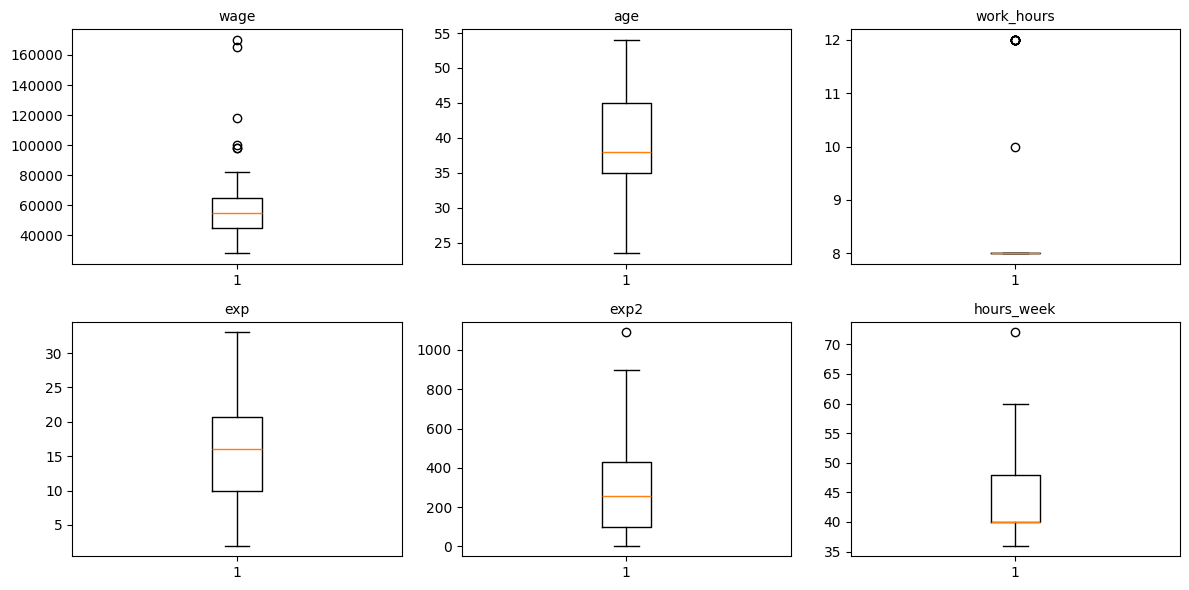

In [ ]:
import matplotlib.pyplot as plt

quant_vars = ["wage", "age", "work_hours", "exp", "exp2", "hours_week"]

plt.figure(figsize=(12, 6))

for i, var in enumerate(quant_vars, 1):
    plt.subplot(2, 3, i)
    plt.boxplot(df_final[var].dropna())
    plt.title(var, fontsize=10)
    plt.tight_layout()

plt.show()


Выбросы:

- wage — выбросы есть: несколько наблюдений с очень высокой зарплатой сильно выделяются.

- age — выбросов нет.

- work_hours — выбросы есть, редкие значения выше 8 часов (10–12).

- exp — выбросов нет, все значения выглядят реалистично.

- exp2 — выбросы есть, но это естественно: большие значения стажа дают резко увеличенный квадрат.

- hours_week — есть выбросы: одно наблюдение около 72 часов сильно выделяется.

## 7. Анализ распределений и показателей асимметрии

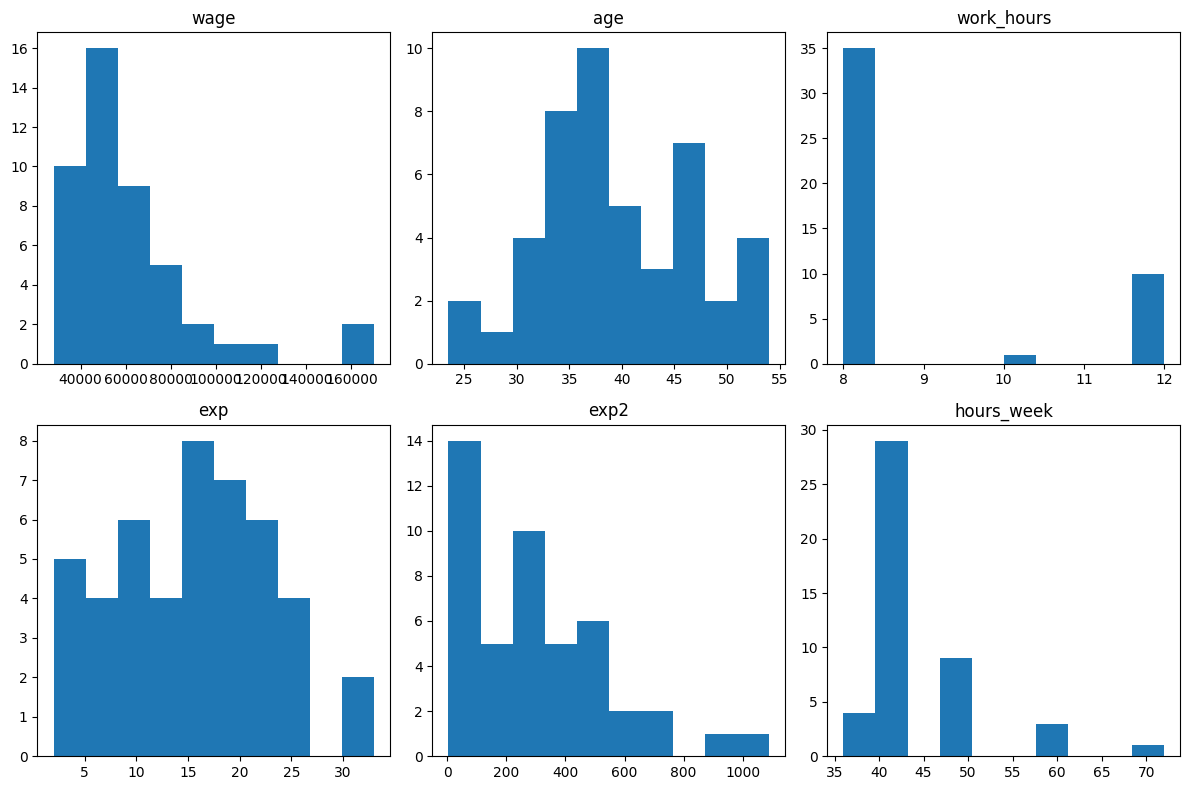

,skewness,kurtosis
wage,2.109208,4.728997
age,0.109301,-0.387094
work_hours,1.294398,-0.279369
exp,0.067189,-0.589425
exp2,1.079937,1.127915
hours_week,2.086704,4.433595


In [ ]:
from scipy.stats import skew, kurtosis

quant_vars = ["wage","age","work_hours","exp","exp2","hours_week"]

plt.figure(figsize=(12, 8))
for i, var in enumerate(quant_vars, 1):
    plt.subplot(2, 3, i)
    plt.hist(df_final[var], bins=10)
    plt.title(var)
plt.tight_layout()
plt.show()

skew_vals = df_final[quant_vars].apply(skew)
kurt_vals = df_final[quant_vars].apply(kurtosis)

stats_sk = pd.DataFrame({
    "skewness": skew_vals,
    "kurtosis": kurt_vals
})

stats_sk


Выводы

- wage: сильная правая асимметрия (skewness около 2). есть редкие высокие зарплаты, которые вытягивают хвост.
Kurtosis > 4, распределение остроконечное, с выбросами.

- age: практически симметричное распределение (skewness около 0.1).
Kurtosis около 0, форма близка к нормальной.

- work_hours: смещение вправо (skewness около 1.29) — много людей с 8 часами, редкие значения 10–12.
Kurtosis около 0, распределение широкое, но без сильной остроты.

- exp: симметричное распределение (skewness около 0.07).
Kurtosis < 0, более плоское, чем нормальное.

- exp2: выраженная правая асимметрия (skewness около 1.07), но это нормально, т.к. большие стажи дают очень большие квадраты.

- hours_week: сильная правая асимметрия (skewness около 2.08).
редкие значения 60–70 часов формируют длинный хвост.
Kurtosis > 4, есть выбросы.

## 8. Структура выборки по уровню образования

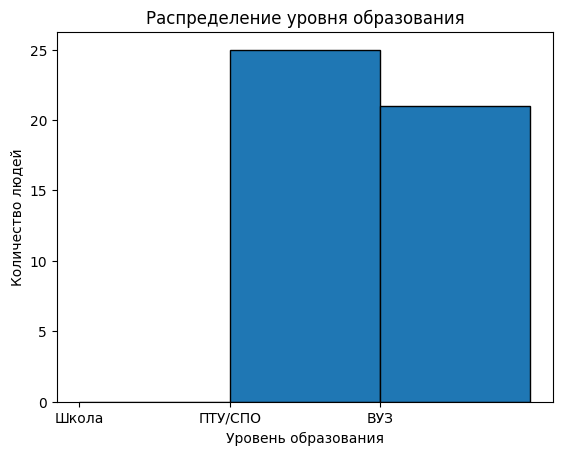

In [ ]:
plt.hist(df_final["educ"], bins=[0,1,2,3], edgecolor='black')
plt.xticks([0, 1, 2], ["Школа", "ПТУ/СПО", "ВУЗ"])
plt.title("Распределение уровня образования")
plt.xlabel("Уровень образования")
plt.ylabel("Количество людей")
plt.show()

- В выборке нет людей только со школьным образованием.

- Больше всего респондентов имеют ПТУ/СПО — эта группа самая крупная.

- Чуть меньше людей имеют высшее образование, но их тоже много.

## 9. Корреляционный анализ переменных

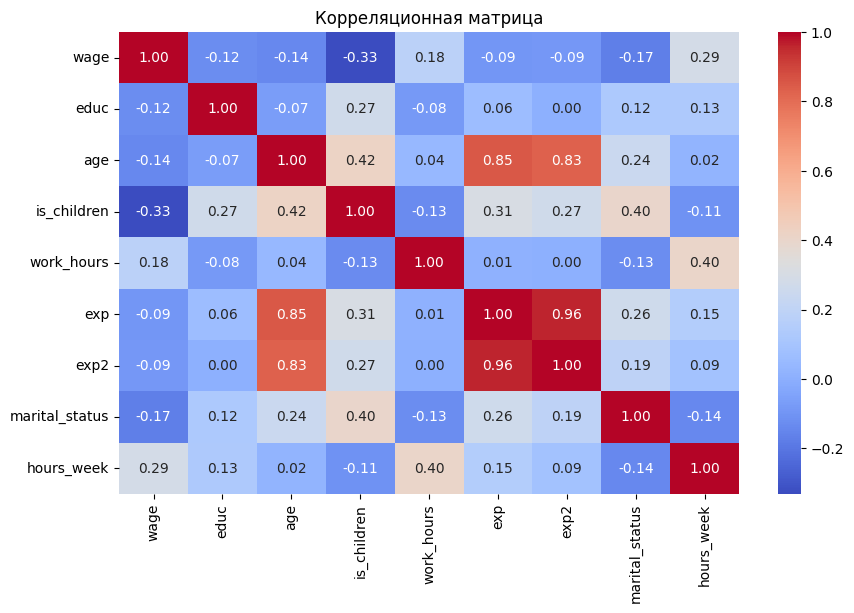

,wage,educ,age,is_children,work_hours,exp,exp2,marital_status,hours_week
wage,1.000000,-0.124770,-0.143182,-0.331245,0.180788,-0.094822,-0.091365,-0.172191,0.287468
educ,-0.124770,1.000000,-0.067236,0.266784,-0.083813,0.059111,0.003204,0.121974,0.127139
age,-0.143182,-0.067236,1.000000,0.417934,0.041719,0.851192,0.831616,0.244496,0.020914
is_children,-0.331245,0.266784,0.417934,1.000000,-0.132149,0.307307,0.266801,0.401312,-0.108988
work_hours,0.180788,-0.083813,0.041719,-0.132149,1.000000,0.007249,0.002365,-0.125419,0.404051
exp,-0.094822,0.059111,0.851192,0.307307,0.007249,1.000000,0.963270,0.263789,0.147658
exp2,-0.091365,0.003204,0.831616,0.266801,0.002365,0.963270,1.000000,0.189399,0.087846
marital_status,-0.172191,0.121974,0.244496,0.401312,-0.125419,0.263789,0.189399,1.000000,-0.139868
hours_week,0.287468,0.127139,0.020914,-0.108988,0.404051,0.147658,0.087846,-0.139868,1.000000


In [ ]:
import seaborn as sns

corr = df_final.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Корреляционная матрица")
plt.show()

corr

Выводы:
- Возраст сильно связан со стажем (corr = 0.85–0.96) — чем старше, тем больше опыт.

- Зарплата слабо связана с опытом (corr = –0.09) — в выборке стаж почти не влияет на доход.

- Зарплата чуть растёт с часами в неделю (corr = 0.29).

- Зарплата меньше у тех, у кого есть дети (corr = –0.33).

- Образование почти ни с чем не связано (corr около 0).

- Семейный статус умеренно связан с наличием детей (corr = 0.40).

- Work_hours почти не коррелирует ни с чем, потому что почти все работают по 8 часов.

## 10. Спецификация модели заработной платы

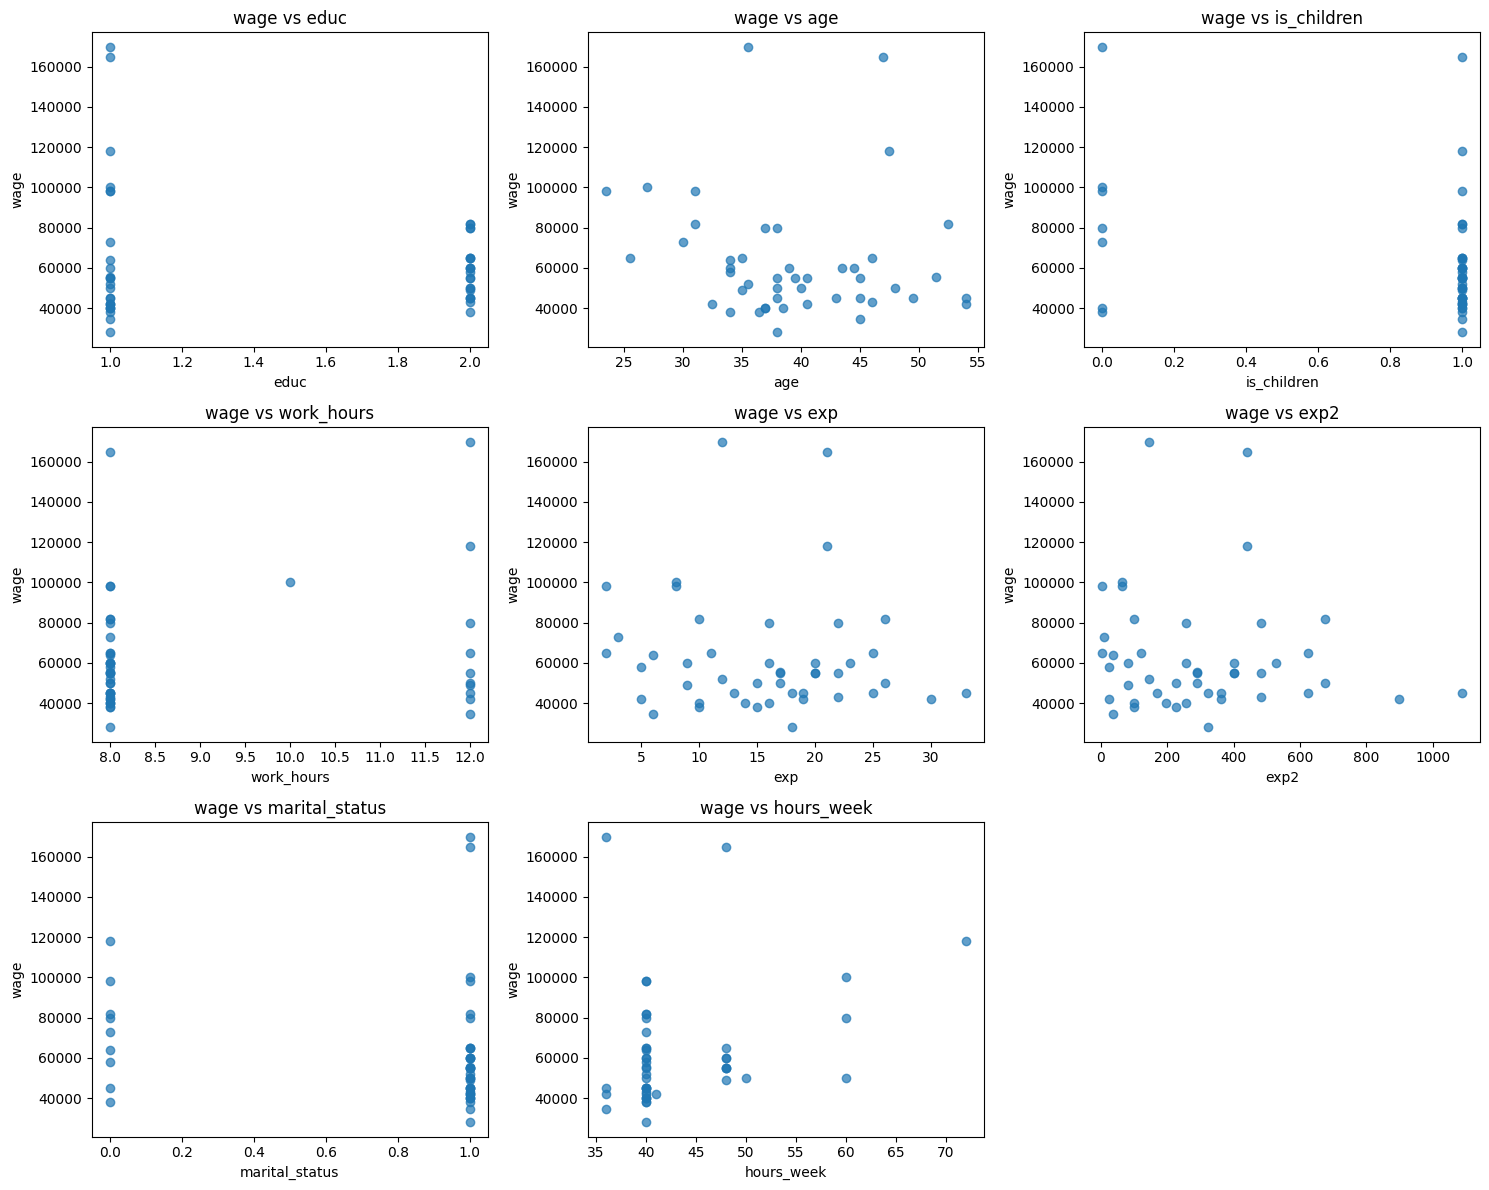

In [ ]:
vars_to_plot = ["educ", "age", "is_children", "work_hours",
                "exp", "exp2", "marital_status", "hours_week"]

plt.figure(figsize=(15, 12))

for i, var in enumerate(vars_to_plot, 1):
    plt.subplot(3, 3, i)
    plt.scatter(df_final[var], df_final["wage"], alpha=0.7)
    plt.title(f"wage vs {var}")
    plt.xlabel(var)
    plt.ylabel("wage")

plt.tight_layout()
plt.show()


Выводы

- educ: люди с высшим образованием (2) в среднем зарабатывают больше, чем с средним профобразованием (1).
Точки выше — это их зарплаты.

- age: чёткой связи нет. Зарплаты разбросаны, возраст влияет слабо.

- is_children: разницы почти нет, дети не связаны с зарплатой.

- work_hours: большинство работает одинаково, поэтому связь слабая.

- exp и exp2: с небольшим ростом опыта зарплата подрастает, но сильной связи нет, точки вразброс.

- marital_status: женатые имеют немного выше зарплаты, но различия небольшие.

- hours_week: кто работает больше часов, тот может зарабатывать больше, но зависимость всё ещё слабая.

## 11. Оценка модели МНК (OLS)

In [ ]:
import statsmodels.api as sm

X = df_final[[
    "educ", "age", "is_children", "work_hours",
    "exp", "exp2", "marital_status", "hours_week"
]]
y = df_final["wage"]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.183
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     1.039
Date:                Wed, 11 Mar 2026   Prob (F-statistic):              0.426
Time:                        13:32:07   Log-Likelihood:                -533.75
No. Observations:                  46   AIC:                             1086.
Df Residuals:                      37   BIC:                             1102.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           4.266e+04   5.14e+04      0.

Выводы:

Модель слабая:

- R^2 = 0.183 — модель объясняет только 18% вариации зарплат.

- Все коэффициент не значимы на уровне 5%, значит статистически значимых факторов в модели нет.

Причины слабой значимости:

- маленькая выборка (46 наблюдений);

- сильная вариативность зарплат;

- низкое разнообразие в переменных (почти у всех 8 рабочих часов, близкие уровни опыта).

Эффекты:

- hours_week - положительный эффект (больше часов → больше зарплата)

- educ - отрицательный знак, но незначим (скорее шум)

- exp и exp2 маленькие и тоже незначимы

Уравнение:

$$
\widehat{wage} =
42660
- 5018.56\, educ
- 101.73\, age
- 2071.12\, is\_children
+ 620.09\, work\_hours
- 248.40\, exp
+ 4.26\, exp^{2}
- 206.78\, marital\_status
+ 1065.29\, hours\_week
$$


## 12. Проверка значимости модели в целом (F-тест)

Тест на незначимость модели в целом:
$$
H_0: \beta_1=\beta_2=\dots=\beta_k = 0 \\
H_1: \text{хотя бы одно } \beta_j \ne 0 \\
$$

Используем F статистику.

$
F = \frac{R^2 / k}{(1 - R^2) / (n - k - 1)} = \frac{0.183 / 8}{(1-0.183)/37} = 1.04\\
\alpha = 0.05 \\
k=8 \\
n−k−1=37 \\
$

Критическое значение:
$
F_{0.95;8;37}=2.23 \\
$

Критическая область:
$
(F_{0.95;8;37}, \infty) \\
(2.23, \infty)
$


$
F < F_{0,95;8;37} \\
1.04 < 2.23 \\
$

Значит не отвергаем гипотезу $H_0$, модель незначима в целом на уровне 5%.

И также в коде:

In [ ]:
fval = model.fvalue
fpval = model.f_pvalue
print(f"F = {fval:.3f}, p-value = {fpval:.4g}")

F = 1.039, p-value = 0.4257
Вывод: не отвергаем H0 (модель в целом незначима)


In [ ]:
alpha = 0.05
print("Вывод:", "отвергаем H0 (модель значима в целом)" if fpval < alpha else "не отвергаем H0 (модель в целом незначима)")

Вывод: не отвергаем H0 (модель в целом незначима)


## 13. Тестирование гипотезы об отдельном коэффициенте (t-тест)

Проверка гипотезы для коэффициента при переменной hours_week:

$$
\begin{aligned}
H_0 &: \beta_{\text{hours_week}} = 0 \\
H_1 &: \beta_{\text{hours_week}} \neq 0
\end{aligned}
$$

Из результатов регрессии:

$$
\hat\beta = 1065.29, \qquad SE = 723.05
$$

Используем t-статистику:

$$
t = \frac{\hat\beta}{SE} = \frac{1065.29}{723.05} = 1.473
$$

Критическое значение:

$$
t_{0.975;37} = 2.026
$$

Критическая область:

$$
(-\infty, -2.026) \cup (2.026, \infty)
$$

Проверка:

$$
|t| = 1.473 < 2.026
$$

Следовательно, гипотеза H_0 не отвергается. Коэффициент при hours_week статистически незначим на уровне значимости 5%.

Оценённый коэффициент показывает, что при увеличении количества рабочих часов в неделю на 1 час заработная плата в среднем увеличивается на 1065.29 руб. при прочих равных. Однако коэффициент статистически незначим, поэтому делать содержательный вывод о наличии такого влияния нельзя.

In [ ]:
var = "hours_week"
tval = model.tvalues[var]
tpval = model.pvalues[var]
bhat = model.params[var]

print(f"{var}: beta_hat = {bhat:.3f}, t = {tval:.3f}, p-value = {tpval:.4g}")

hours_week: beta_hat = 1065.282, t = 1.473, p-value = 0.1491


In [ ]:
alpha = 0.05
print("Вывод:", "отвергаем H0 (коэффициент значим)" if tpval < alpha else "не отвергаем H0 (коэффициент незначим)")

Вывод: не отвергаем H0 (коэффициент незначим)


## 14. Совместная проверка коэффициентов (F-тест ограничений)


Проверим совместную значимость для exp и age:

In [ ]:
import statsmodels.api as sm

X_full = df_final[["educ", "age", "is_children", "work_hours",
             "exp", "exp2", "marital_status", "hours_week"]]

X_full = sm.add_constant(X_full)
y = df_final["wage"]

model_full = sm.OLS(y, X_full).fit()
SSR_UR = model_full.ssr


X_rest = df_final[["educ", "is_children", "work_hours",
             "exp2", "marital_status", "hours_week"]]

X_rest = sm.add_constant(X_rest)

model_rest = sm.OLS(y, X_rest).fit()
SSR_R = model_rest.ssr

print("RSS полной модели (UR):", SSR_UR)
print("RSS ограниченной модели (R):", SSR_R)


RSS полной модели (UR): 32266498148.46258
RSS ограниченной модели (R): 32287045764.21355


Проверка гипотезы о совместной значимости коэффициентов при переменных age и exp:

$$
H_0: \beta_{age}=0,\ \beta_{exp}=0
$$

$$
H_1: \beta_{age}\neq 0 \ \text{или}\ \beta_{exp}\neq 0
$$

Используем F-статистику:

$$
F = \frac{(RSS_R-RSS_{UR}) / q}{RSS_{UR} / (n-k-1)}
$$

где \(q=2\) — число ограничений.

$$
F = \frac{(32287045764.214 - 32266498148.463)/2}{32266498148.463/37}
\approx 0.012
$$

При уровне значимости \(\alpha=0.05\) критическое значение равно:

$$
F_{0.95;2;37}
$$

Критическая область:

$$
F > F_{0.95;2;37}
$$

Поскольку расчётное значение статистики меньше критического, гипотеза H_0 не отвергается.

Следовательно, коэффициенты при переменных age и exp совместно незначимы на уровне значимости 5%.

In [ ]:
ft = model.f_test("exp = 0, age = 0")
fval = float(ft.fvalue)
fpval = float(ft.pvalue)
print(f"F = {fval:.3f}, p-value = {fpval:.4g}")
alpha = 0.05
print("Вывод:", "отвергаем H0" if fpval < alpha else "не отвергаем H0")

F = 0.012, p-value = 0.9883
Вывод: не отвергаем H0


## 15. Диагностика остатков модели

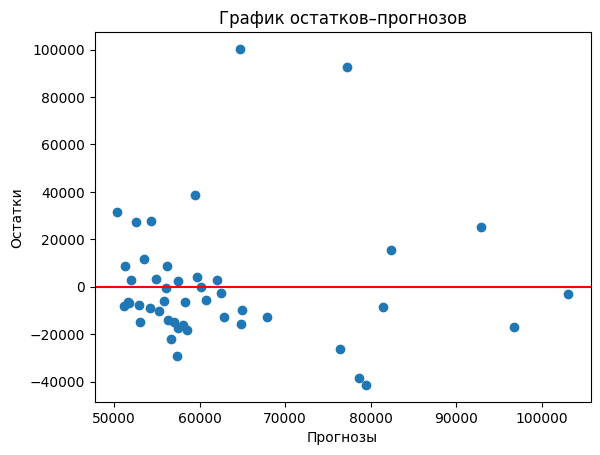

In [ ]:
import matplotlib.pyplot as plt

y_pred = model.predict(X)
residuals = model.resid

plt.scatter(y_pred, residuals)
plt.axhline(0, color='red')
plt.xlabel("Прогнозы")
plt.ylabel("Остатки")
plt.title("График остатков–прогнозов")
plt.show()


Остатки распределены неравномерно и сильно разбросаны, особенно при больших значениях прогноза.
Это показывает, что модель плохо объясняет данные и даёт неточные прогнозы для части наблюдений.

## 16. Сравнение и отбор спецификаций модели



Все коэффициенты в полной модели оказались незначимым на 5% уровне — p-value у всех больше 0.05.

Значит, если строго следовать условию, в модели остаётся только константа.



$$
\widehat{wage} =
42660
$$

Это просто среднее значение заработной платы из выборки.

Если сравнивать с моделью в п.10, то теперь количество переменных = 0, а не 9. Также R^2 = 0, а не 0.183. Такая же ситуация с R^2 adj. По этим критериям мы можем сравнить модели. Также можно использовать AIC и BIC.

Вывод: Полная модель, хоть и даёт незначимые коэффициенты, всё же объясняет часть вариации зарплат.
Модель только с константой практически бесполезна.

## 17. Тестирование и корректировка выбросов

In [ ]:
import numpy as np
import statsmodels.api as sm

# модель
cols = ["educ","age","is_children","work_hours","exp","exp2","marital_status","hours_week"]
X = sm.add_constant(df_final[cols])
y = df_final["wage"]
model = sm.OLS(y, X).fit()
inf = model.get_influence()

# IQR
iqr_outliers = {}
for col in ["wage","educ","age","work_hours","exp","exp2","hours_week"]:
    Q1, Q3 = df_final[col].quantile(0.25), df_final[col].quantile(0.75)
    IQR = Q3 - Q1
    iqr_outliers[col] = df_final[(df_final[col] < Q1 - 1.5*IQR) | (df_final[col] > Q3 + 1.5*IQR)].index.tolist()

# Leverage
lev = inf.hat_matrix_diag
lev_pos = np.where(lev > 2*(X.shape[1])/X.shape[0])[0]
lev_idx = df_final.index[lev_pos].tolist()

# Cook
cooks = inf.cooks_distance[0]
cooks_pos = np.where(cooks > 4/X.shape[0])[0]
cooks_idx = df_final.index[cooks_pos].tolist()

print("IQR:", iqr_outliers)
print("Leverage idx:", lev_idx)
print("Cook idx:", cooks_idx)

out_idx = set(
    iqr_outliers["wage"]
    + iqr_outliers["work_hours"]
    + iqr_outliers["hours_week"]
    + iqr_outliers["exp2"]
    + lev_idx
    + cooks_idx
)

df_clean = df_final.drop(index=out_idx)

X_clean = sm.add_constant(df_clean[cols])
y_clean = df_clean["wage"]
model_clean = sm.OLS(y_clean, X_clean).fit()

print("Размер исходных данных:", len(df_final))
print("Размер после удаления выбросов:", len(df_clean))
print(model_clean.summary())


IQR: {'wage': [3341, 7801, 7828, 11124, 11127, 11157], 'educ': [], 'age': [], 'work_hours': [3337, 3341, 3353, 5887, 7828, 8615, 9523, 10524, 10536, 11124, 11155], 'exp': [], 'exp2': [8206], 'hours_week': [3341]}
Leverage idx: [3337, 3341, 3353, 8206, 8615]
Cook idx: [3341, 7801, 7828, 8614]
Размер исходных данных: 46
Размер после удаления выбросов: 30
                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.356
Model:                            OLS   Adj. R-squared:                  0.151
Method:                 Least Squares   F-statistic:                     1.734
Date:                Wed, 11 Mar 2026   Prob (F-statistic):              0.153
Time:                        14:06:11   Log-Likelihood:                -320.87
No. Observations:                  30   AIC:                             657.7
Df Residuals:                      22   BIC:                             669.0
Df Model:    

Я удалил выбросы, которые были в модели.

Основные изменения:

- R^2 adj немного вырос (с 0.183 до 0.356), модель объясняет больше вариации зарплаты.

- R^2 adj вырос (с 0.007 до 0.151), но остался низким, качество всё ещё слабое.

- P-value F-теста снизилось (с 0.426 до 0.153), но модель всё ещё статистически незначима.

Итог: удаление выбросов улучшило модель (выше R^2, меньше шум), но значимых коэффициентов всё равно нет — модель остаётся слабой.



## 18. Точечный и интервальный прогноз

In [ ]:
import pandas as pd

new_person = pd.DataFrame([{
    "educ": 2,
    "age": 40,
    "is_children": 1,
    "work_hours": 8,
    "exp": 15,
    "exp2": 225,
    "marital_status": 1,
    "hours_week": 40
}])

new_person = sm.add_constant(new_person, has_constant='add')

new_person = new_person[model_clean.model.exog_names]

pred = model_clean.get_prediction(new_person)

pred.summary_frame()

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,55055.246673,4269.737033,46200.354033,63910.139313,27699.542918,82410.950428


Точечный прогноз заработной платы:

Модель:
$$
\widehat{wage}
= 42660
-5018.56\, educ
-101.73\, age
-2071.12\, is\_children
+620.09\, work\_hours
-248.40\, exp
+4.26\, exp^2
-206.78\, marital\_status
+1065.29\, hours\_week
$$

Характеристики индивида:
- educ=2,
- age=40,
- is_children=1,
- work_hours=8,
- exp=15,
- exp^2=225,
- marital_status=1,
- hours_week=40


Подставляем:
$$
\widehat{wage} =
42660
- 5018.56 \cdot 2
- 101.73 \cdot 40
- 2071.12 \cdot 1
+ 620.09 \cdot 8
- 248.40 \cdot 15
+ 4.26 \cdot 225
- 206.78 \cdot 1
+ 1065.29 \cdot 40
$$


$\widehat{wage} \approx 75480 \text{ руб.}$


Доверительный интервал прогноза:
$
\widehat{wage} \pm t_{0.975;37}\cdot SE(\widehat{y}_{pred})
$

Критическое значение:
$
t_{0.975;37} = 2.026
$

$SE(\widehat{y}_{pred})$ посчитал с помощью кода выше, но можно также было через корреляционную таблицу и значение дисперсии. Берем значение $mean_se = 8055$. Так просто гораздо проще и быстрее.

Подставляем в формулу:
$
75480 \pm 2.026\cdot 8055
$

$
CI_{95\%} = [59160,57; 91799,43]
$

## 19. Общие итоги проекта

В первой части проекта была проведена подготовка и первичный анализ данных. Выборка была очищена от пропусков и некорректных наблюдений, а также были сформированы дополнительные переменные, необходимые для дальнейшего анализа.

Был выполнен разведочный анализ данных: рассчитаны описательные статистики, исследованы распределения переменных и выявлены возможные выбросы. Это позволило лучше понять структуру данных и особенности распределения заработной платы.

Далее был проведён анализ взаимосвязей между заработной платой и объясняющими факторами. Были выявлены переменные, которые потенциально могут влиять на уровень дохода.

На основе полученных данных была построена линейная регрессионная модель и проведена проверка статистической значимости факторов. После этого была выполнена диагностика модели и корректировка её спецификации.

В заключение был рассчитан точечный прогноз заработной платы для заданных характеристик индивида и построен доверительный интервал прогнозного значения.

# Часть 2. Эконометрическое моделирование заработной платы

##1. Полулогарифмическая модель заработной платы

$
\ln(wage_i)
=
\beta_0
+\beta_1\,educ_i
+\beta_2\,age_i
+\beta_3\,is\_children_i
+\beta_4\,work\_hours_i
+\beta_5\,exp_i
+\beta_6\,exp_i^2
+\beta_7\,marital\_status_i
+\beta_8\,hours\_week_i
+u_i
$

In [4]:
import pandas as pd, numpy as np, statsmodels.api as sm

df=pd.read_csv("dataset_res.csv")
y=np.log(df["wage"])
X=sm.add_constant(df[["educ","age","is_children","work_hours","exp","exp2","marital_status","hours_week"]])

m_log=sm.OLS(y,X).fit()

m_log.summary()
m_log.params


,0
const,10.733295
educ,0.003086
age,-0.004444
is_children,-0.211820
work_hours,-0.004014
exp,-0.015698
exp2,0.000469
marital_status,-0.056524
hours_week,0.017744


$
\widehat{\ln(wage_i)}=
10.7333
+0.00309\,educ_i
-0.00444\,age_i
-0.21182\,is\_children_i
-0.00401\,work\_hours_i
-0.01570\,exp_i
+0.000469\,exp_i^2
-0.05652\,marital\_status_i
+0.01774\,hours\_week_i
$


In [5]:
import statsmodels.api as sm
import numpy as np

X=df[["educ","age","is_children","work_hours","exp","exp2","marital_status","hours_week"]]
y=np.log(df["wage"])

X=sm.add_constant(X)
model=sm.OLS(y,X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.211
Model:                            OLS   Adj. R-squared:                  0.040
Method:                 Least Squares   F-statistic:                     1.237
Date:                Wed, 11 Mar 2026   Prob (F-statistic):              0.306
Time:                        21:12:47   Log-Likelihood:                -15.045
No. Observations:                  46   AIC:                             48.09
Df Residuals:                      37   BIC:                             64.55
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             10.7333      0.651     16.

Выводы:

- Все коэффициенты не значимы на уровне 5%, т.к. для всех регрессоров p_value > 0.05. Наиболее близкой к значимости является переменная hours_week (p_value = 0.060)

- F-статистика равна 1.237, соответствующее значение P(F-statistic)=0.306.
Значит, нулевая гипотеза о совместной незначимости коэффициентов не отвергается, и модель не значима в целом.

- Полулогарифмическая модель несколько улучшает описание распределения заработной платы по сравнению с линейной моделью. Но большинство коэффициентов остаются незначимыми, а объясняющая способность модели остаётся низкой.

## 2. Лог-линейная спецификация модели

Количественные переменные берем в логарифмах, качественные переменные оставляем в исходном виде:

$
\ln(wage_i)
=
\beta_0
+\beta_1\,educ_i
+\beta_2\,\ln(age_i)
+\beta_3\,is\_children_i
+\beta_4\,\ln(work\_hours_i)
+\beta_5\,\ln(exp_i)
+\beta_6\,\bigl(\ln(exp_i)\bigr)^2
+\beta_7\,marital\_status_i
+\beta_8\,\ln(hours\_week_i)
+u_i
$


In [6]:
import pandas as pd, numpy as np, statsmodels.api as sm

X=sm.add_constant(pd.DataFrame({
    "educ":df["educ"],
    "ln_age":np.log(df["age"]),
    "is_children":df["is_children"],
    "ln_work_hours":np.log(df["work_hours"]),
    "ln_exp":np.log(df["exp"]),
    "ln_exp2":np.log(df["exp"])**2,
    "marital_status":df["marital_status"],
    "ln_hours_week":np.log(df["hours_week"])
}))

m3=sm.OLS(y,X).fit()
m3.summary()
m3.params


,0
const,9.499460
educ,-0.015489
ln_age,-0.297460
is_children,-0.179407
ln_work_hours,0.043288
ln_exp,-0.345329
ln_exp2,0.078681
marital_status,-0.065061
ln_hours_week,0.804123


$
\widehat{\ln(wage_i)}=
9.4995
-0.0155\,educ_i
-0.2975\,\ln(age_i)
-0.1794\,is\_children_i
+0.0433\,\ln(work\_hours_i)
-0.3453\,\ln(exp_i)
+0.0787\,\bigl(\ln(exp_i)\bigr)^2
-0.0651\,marital\_status_i
+0.8041\,\ln(hours\_week_i)
$


In [7]:
import statsmodels.api as sm
import numpy as np

y=np.log(df["wage"])

X=sm.add_constant(pd.DataFrame({
    "educ":df["educ"],
    "ln_age":np.log(df["age"]),
    "is_children":df["is_children"],
    "ln_work_hours":np.log(df["work_hours"]),
    "ln_exp":np.log(df["exp"]),
    "ln_exp2":np.log(df["exp"])**2,
    "marital_status":df["marital_status"],
    "ln_hours_week":np.log(df["hours_week"])
}))

model=sm.OLS(y,X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.219
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     1.298
Date:                Wed, 11 Mar 2026   Prob (F-statistic):              0.275
Time:                        21:12:53   Log-Likelihood:                -14.805
No. Observations:                  46   AIC:                             47.61
Df Residuals:                      37   BIC:                             64.07
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              9.4995      2.798      3.

Выводы:

- На уровне значимости 5% ни один из коэффициентов модели не является статистически значимым, поскольку для всех объясняющих переменных p_value>0.05. Переменная hours_week в логарифмах является наиболее близкой к границе значимости (p_value=0.078), однако статистически значимой на 5% уровне она не является.

- Значение F-статистики = 1.298, при P(F-statistic)=0.275. Таким образом, нулевая гипотеза о совместной незначимости коэффициентов не отвергается, и модель не является значимой в целом.

- Использование логарифмов объясняющих переменных позволяет несколько улучшить форму модели по сравнению с линейной моделью, но существенного улучшения качества модели и значимости коэффициентов нет, а объясняющая способность остаётся низкой.

##3. Сравнение альтернативных спецификаций модели

Для сравнения буду смотреть на:

- статистическая значимость модели в целом (F-тест);

- значимость отдельных коэффициентов;

- значение R2

- экономическая интерпретация коэффициентов;

Сравнительный анализ:

- Линейная модель в уровнях показала наихудшие результаты: она слабо объясняет различия в заработной плате и не выявляет значимого влияния ни одного из факторов. Кроме того, такая форма плохо учитывает асимметрию распределения заработной платы.

- Полулогарифмическая модель частично решает эту проблему за счёт логарифмирования заработной платы. Интерпретация коэффициентов становится более удобной, однако значимых коэффициентов и существенного улучшения качества модели нет.

- Линейная в логарифмах модель демонстрирует наибольшее значение R2
и более удобную экономическую интерпретацию коэффициентов (в терминах эластичностей), однако статистическая значимость коэффициентов и модели в целом остаётся низкой. По сравнению с другими спецификациями она лучше описывает относительные изменения заработной платы и демонстрирует немного более высокие показатели качества модели.

Выбор модели:

Выбираю линейная в логарифмах модель, поскольку она:

- лучше соответствует распределению заработной платы;

- обеспечивает наиболее интерпретируемые параметры;

- демонстрирует наилучшие показатели качества среди рассмотренных моделей.

Вывод

Несмотря на то что ни одна из рассмотренных моделей не является статистически значимой, линейная в логарифмах модель выглядит наиболее предпочтительной среди альтернатив.

## 4. Проверка структурных различий: тест Чоу

Буду дальше использовать 3 модель с линейной моделью в логарифмах, т.к. она показала лучшие результаты.

RSS_r = 0.219

Использую переменную is_children, отражающую наличие детей.

1. Дамми переменные:

В исходную модель добавляются произведения бинарной переменной is_children на все объясняющие переменные:

$
\ln(wage_i)
=
\beta_0
+\beta_1 X_i
+\gamma_0\,is\_children_i
+\gamma_1\,(is\_children_i \cdot X_i)
+u_i
$

X_i — вектор объясняющих переменных выбранной модели.

Гитотезы теста Чоу:

$
H_0:\ \gamma_0=\gamma_1=\dots=\gamma_k=0
$

$
H_1:\ \exists\, j:\ \gamma_j \neq 0
$

Посчитаем в коде RSS_u и RSS_r:

In [8]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

y = np.log(df["wage"])

Xr = sm.add_constant(pd.DataFrame({
    "educ": df["educ"],
    "ln_age": np.log(df["age"]),
    "ln_work_hours": np.log(df["work_hours"]),
    "ln_exp": np.log(df["exp"]),
    "ln_exp2": np.log(df["exp"])**2,
    "marital_status": df["marital_status"],
    "ln_hours_week": np.log(df["hours_week"])
}))

mr = sm.OLS(y, Xr).fit()
RSS_r = mr.ssr

Xu = Xr.copy()
Xu["group"] = df["is_children"]

for c in Xr.columns:
    if c != "const":
        Xu[c + "_int"] = Xr[c] * df["is_children"]

mu = sm.OLS(y, Xu).fit()
RSS_u = mu.ssr

RSS_r, RSS_u

(np.float64(5.242430070222322), np.float64(2.9950138482477793))

In [9]:
from scipy.stats import f

f.ppf(0.95, 8, 30)

np.float64(2.2661632741381412)

RSS_r = 5.2424

RSS_u = 2.9950

Формула F статистики:

$
F=
\frac{(RSS_R-RSS_U)/q}{RSS_U/(n-k-q)}
$

Подставляем наши значения:

$ F = \frac{(5.2424-2.9950)/8}{2.9950/(46-8-8)} = 2.81$

Критическая область: $(2.81, +\infty)$

$F_{0.95;8;30}​ = 2.26$

2.26 < 2.81, гипотеза H_0 отвеграется. Значит имеются структурные различия в модели между группами индивидов с детьми и без детей.

2. Классический тест Чоу

Разделяем модель на подвыборки (где is_children=0 и is_children=1):

1. $
y_i
=
\beta_0^{(0)}
+\beta_1^{(0)} x_{1i}
+\dots
+\beta_k^{(0)} x_{ki}
+u_i^{(0)}
$

2. $
y_i
=
\beta_0^{(1)}
+\beta_1^{(1)} x_{1i}
+\dots
+\beta_k^{(1)} x_{ki}
+u_i^{(1)}
$

Гипотезы:

$
H_0:\ \beta^{(0)}=\beta^{(1)}
$

$
H_1:\ \beta^{(0)}\neq \beta^{(1)}
$



В подвыборочных моделях переменная is_children не включается в число объясняющих переменных, так как внутри каждой группы она является константой.

In [10]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import f

df0 = df[df["is_children"] == 0].copy()
df1 = df[df["is_children"] == 1].copy()

y_p = np.log(df["wage"])
X_p = sm.add_constant(pd.DataFrame({
    "educ": df["educ"],
    "ln_age": np.log(df["age"]),
    "ln_work_hours": np.log(df["work_hours"]),
    "ln_exp": np.log(df["exp"]),
    "ln_exp2": np.log(df["exp"])**2,
    "marital_status": df["marital_status"],
    "ln_hours_week": np.log(df["hours_week"])
}))
RSS_p = sm.OLS(y_p, X_p).fit().ssr

y0 = np.log(df0["wage"])
X0 = sm.add_constant(pd.DataFrame({
    "educ": df0["educ"],
    "ln_age": np.log(df0["age"]),
    "ln_work_hours": np.log(df0["work_hours"]),
    "ln_exp": np.log(df0["exp"]),
    "ln_exp2": np.log(df0["exp"])**2,
    "marital_status": df0["marital_status"],
    "ln_hours_week": np.log(df0["hours_week"])
}))
RSS_0 = sm.OLS(y0, X0).fit().ssr

y1 = np.log(df1["wage"])
X1 = sm.add_constant(pd.DataFrame({
    "educ": df1["educ"],
    "ln_age": np.log(df1["age"]),
    "ln_work_hours": np.log(df1["work_hours"]),
    "ln_exp": np.log(df1["exp"]),
    "ln_exp2": np.log(df1["exp"])**2,
    "marital_status": df1["marital_status"],
    "ln_hours_week": np.log(df1["hours_week"])
}))
RSS_1 = sm.OLS(y1, X1).fit().ssr

RSS_p, RSS_0, RSS_1

(np.float64(5.242430070222322),
 np.float64(3.1617545081258153e-27),
 np.float64(2.995013848247776))

Нашли в коде

$RSS_p​=5.2424$

$RSS_0 = 3.1618 \cdot 10^{-27}$

$RSS_1 = 2.9950$

Ищем F статистику:

$F = \dfrac{(RSS_p - (RSS_0 + RSS_1))/k}{(RSS_0 + RSS_1)/(n_0 + n_1 - 2k)} = \dfrac{(5.2424−2.9950)/8}{2.9950/(46-16)} = 2.81$

Критичсекая область: $(2.81, +\infty)$

$F_{0.95;8;30}​ = 2.26$

2.26 < 2.81, нулевая гипотеза отвергается.

Вывод:

Видим, что как в тесте с дамми-переменными, так и в классическом тесте Чоу нулевая гипотеза отвергается.

Это означает, что имеются статистически значимые структурные различия в коэффициентах модели между группами индивидов с детьми и без детей.

При этом значения F-статистики находятся не сильно далеко от границы критической области, что может быть связано с небольшим размером подвыборок.

В целом результаты тестов указывают на наличие структурных различий в зависимости факторов заработной платы для рассматриваемых групп, однако интерпретировать их следует с осторожностью из-за ограниченного объёма выборки.

##5. Диагностика мультиколлинеарности регрессоров

Для проверки мультиколлинеарности посмотрим на корреляционную матрицу.

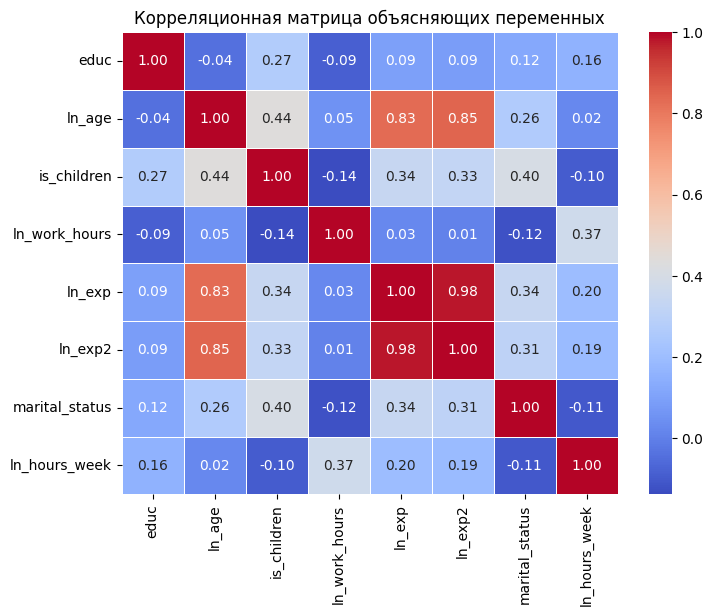

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

X = pd.DataFrame({
    "educ": df["educ"],
    "ln_age": np.log(df["age"]),
    "is_children": df["is_children"],
    "ln_work_hours": np.log(df["work_hours"]),
    "ln_exp": np.log(df["exp"]),
    "ln_exp2": np.log(df["exp"])**2,
    "marital_status": df["marital_status"],
    "ln_hours_week": np.log(df["hours_week"])
})

corr = X.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Корреляционная матрица объясняющих переменных")
plt.show()

- Самая сильная связь — между ln_exp и ln_exp2 (почти 1), это источник мультиколлинеарности.

- Также заметна высокая корреляция ln_age с ln_exp и ln_exp2 (около 0.83–0.85), что логично: возраст связан со стажем.

- Остальные корреляции умеренные или слабые.

Посмотрим на VIF - коэффициенты инфляции дисперсии. Повышенные значения - показатель мультиколлинеарности.

In [12]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

Xc=sm.add_constant(X)
pd.Series([variance_inflation_factor(Xc.values,i) for i in range(Xc.shape[1])], index=Xc.columns).sort_values(ascending=False)


,0
const,2598.637273
ln_exp2,31.922093
ln_exp,29.811727
ln_age,4.841462
is_children,1.650368
ln_hours_week,1.408324
marital_status,1.342171
ln_work_hours,1.259565
educ,1.234713


Для выявления мультиколлинеарности используется показатель VIF. Обычно считается, что при VIF > 10 наблюдается сильная мультиколлинеарность. В полученных результатах очень высокие значения VIF имеют переменные ln_exp (29.81) и ln_exp^2 (31.92), что указывает на сильную мультиколлинеарность между ними. Остальные переменные имеют значения VIF значительно ниже 10, поэтому серьёзной проблемы мультиколлинеарности для них не наблюдается.

Чтобы это исправить используем центрирование логарифма стажа. Заменим ln(exp), ln(exp)^2 на z^2, $z=\ln(exp)-\overline{\ln(exp)}$

In [13]:
import numpy as np, pandas as pd, statsmodels.api as sm

df["ln_exp"]=np.log(df["exp"])
df["ln_exp_c"]=df["ln_exp"]-df["ln_exp"].mean()
df["ln_exp_c2"]=df["ln_exp_c"]**2

X=sm.add_constant(pd.DataFrame({
    "educ":df["educ"],
    "ln_age":np.log(df["age"]),
    "is_children":df["is_children"],
    "ln_work_hours":np.log(df["work_hours"]),
    "ln_exp_c":df["ln_exp_c"],
    "ln_exp_c2":df["ln_exp_c2"],
    "marital_status":df["marital_status"],
    "ln_hours_week":np.log(df["hours_week"])
}))

y=np.log(df["wage"])
model=sm.OLS(y,X).fit()
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   wage   R-squared:                       0.219
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     1.298
Date:                Wed, 11 Mar 2026   Prob (F-statistic):              0.275
Time:                        21:13:27   Log-Likelihood:                -14.805
No. Observations:                  46   AIC:                             47.61
Df Residuals:                      37   BIC:                             64.07
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              9.1321      3.020      3.024      0.005       3.013      15.251
educ              -0.0155      0.122     -0.127      0.900      -0.264       0.233
ln_age            -0.2975      0.643     -0.462      0.647      -1.601       1.006
is_children       -0.1794      0.196     -0.914      0.367      -0.577       0.218
ln_work_hours      0.0433      0.367      0.118      0.907      -0.700       0.787
ln_exp_c           0.0603      0.217      0.278      0.783      -0.379       0.500
ln_exp_c2          0.0787      0.108      0.731      0.469      -0.139       0.297
marital_status    -0.0651      0.160     -0.406      0.687      -0.390       0.260
ln_hours_week      0.8041      0.444      1.813      0.078      -0.095       1.703
==============================================================================
Omnibus:                       17.538   Durbin-Watson:                   1.871
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               23.172
Skew:                           1.266   Prob(JB):                     9.30e-06
Kurtosis:                       5.384   Cond. No.                         342.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

Xc=sm.add_constant(X.drop(columns="const"))
pd.Series([variance_inflation_factor(Xc.values,i) for i in range(Xc.shape[1])], index=Xc.columns)


,0
const,3027.868945
educ,1.234713
ln_age,4.841462
is_children,1.650368
ln_work_hours,1.259565
ln_exp_c,6.653395
ln_exp_c2,2.243038
marital_status,1.342171
ln_hours_week,1.408324


После центрирования стажа значения VIF для всех объясняющих переменных находятся на приемлемом уровне. Самые большие VIF наблюдаются у ln_exp_c (=6.65) и ln_age (=4.84), но они не превышают критических порогов (10), поэтому серьёзной мультиколлинеарности в модели больше нет. В целом центрирование заметно улучшило ситуацию, и модель можно считать устойчивой с точки зрения мультиколлинеарности.

##6. Применение метода главных компонент (PCA)

Применение метода главных компонент уместно, т.к. в модели ранее была мультиколлинеарность между объясняющими переменными. МГК позволяет заменить коррелированные регрессоры на некоррелированные линейные комбинации, тем самым устраняя мультиколлинеарность.

МГК применяется для:

- устранения мультиколлинеарности

- снижения размерности данных

- построения более устойчивых регрессионных моделей

- анализа структуры данных и выявления основных факторов вариации

МГК применим технически, но для интерпретируемой эконометрической модели предпочтительнее центрирование, а не переход к главным компонентам.
Кроме того, метод ориентирован на объяснение вариации регрессоров, а не зависимой переменной, что не всегда оптимально для эконометрического анализа.

In [15]:
import numpy as np, pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

Z=pd.DataFrame({
    "educ":df["educ"],
    "ln_age":np.log(df["age"]),
    "ln_work_hours":np.log(df["work_hours"]),
    "ln_exp":np.log(df["exp"]),
    "ln_hours_week":np.log(df["hours_week"])
})

Zs=StandardScaler().fit_transform(Z)
pca=PCA().fit(Zs)

expl=pca.explained_variance_ratio_
expl.cumsum()


array([0.37704131, 0.64478723, 0.85936259, 0.97244139, 1.        ])

In [16]:
PC = pca.transform(Zs)[:, :2]

X = pd.DataFrame(PC, columns=["PC1", "PC2"], index=df.index)
X = sm.add_constant(X)

y = np.log(df["wage"])

sm.OLS(y, X).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   wage   R-squared:                       0.131
Model:                            OLS   Adj. R-squared:                  0.091
Method:                 Least Squares   F-statistic:                     3.252
Date:                Wed, 11 Mar 2026   Prob (F-statistic):             0.0484
Time:                        21:13:34   Log-Likelihood:                -17.256
No. Observations:                  46   AIC:                             40.51
Df Residuals:                      43   BIC:                             46.00
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.9649      0.054    204.200      0.000      10.857      11.073
PC1           -0.0291      0.039     -0.745      0.460      -0.108       0.050
PC2            0.1132      0.046      2.439      0.019       0.020       0.207
==============================================================================
Omnibus:                       12.750   Durbin-Watson:                   1.758
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               13.842
Skew:                           1.039   Prob(JB):                     0.000987
Kurtosis:                       4.705   Cond. No.                         1.37
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

- Первые две главные компоненты объясняют значительную часть вариации исходных регрессоров (около 64% — первая и около 86% — первые две вместе), поэтому использовать их вместо исходных переменных допустимо.

- В регрессии на главные компоненты вторая компонента (PC2) оказалась статистически значимой на уровне 5%, тогда как первая компонента (PC1) — нет.

- Модель в целом является значимой (P(F-statistic)=0.048), а значение условного числа низкое, что говорит об отсутствии проблем мультиколлинеарности.

- При этом коэффициенты при главных компонентах не имеют прямой экономической интерпретации, поэтому модель с МГК удобна для повышения устойчивости и значимости, но менее информативна с точки зрения экономического смысла факторов.

##7. Диагностика модели на основе анализа остатков

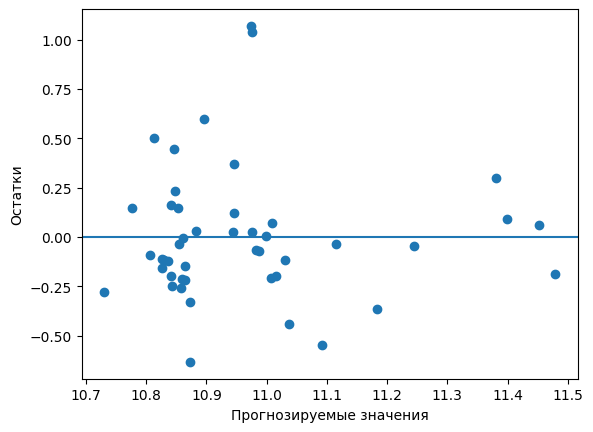

In [17]:
import matplotlib.pyplot as plt
import numpy as np, statsmodels.api as sm

y=np.log(df["wage"])

X=sm.add_constant(pd.DataFrame({
    "educ":df["educ"],
    "ln_age":np.log(df["age"]),
    "is_children":df["is_children"],
    "ln_work_hours":np.log(df["work_hours"]),
    "ln_exp":np.log(df["exp"]),
    "ln_exp2":np.log(df["exp"])**2,
    "marital_status":df["marital_status"],
    "ln_hours_week":np.log(df["hours_week"])
}))

m=sm.OLS(y,X).fit()

y_hat=m.fittedvalues
res=m.resid

plt.figure()
plt.scatter(y_hat,res)
plt.axhline(0)
plt.xlabel("Прогнозируемые значения")
plt.ylabel("Остатки")
plt.show()


- Остатки в среднем распределены вокруг нулевой линии, систематического смещения нет.

- Явной зависимости остатков от прогнозируемых значений нет.

- Это указывает на корректный выбор функциональной формы модели.

- Вместе с тем разброс остатков достаточно велик, что говорит о невысокой точности модели и возможном наличии неучтённых факторов.

##8. Проверка гетероскедастичности остатков

1. Тест Бреуша–Пагана

In [18]:
import numpy as np, statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

y=np.log(df["wage"])
X=sm.add_constant(pd.DataFrame({
    "educ":df["educ"],
    "ln_age":np.log(df["age"]),
    "is_children":df["is_children"],
    "ln_work_hours":np.log(df["work_hours"]),
    "ln_exp":np.log(df["exp"]),
    "ln_exp2":np.log(df["exp"])**2,
    "marital_status":df["marital_status"],
    "ln_hours_week":np.log(df["hours_week"])
}))

m=sm.OLS(y,X).fit()

bp=het_breuschpagan(m.resid, m.model.exog)
bp


(np.float64(8.691162001993233),
 np.float64(0.3690151610766026),
 np.float64(1.0774022032357649),
 np.float64(0.3998271501800994))

2. Тест Уайта

In [19]:
from statsmodels.stats.diagnostic import het_white

white=het_white(m.resid, m.model.exog)
white


(np.float64(40.30615804904123),
 np.float64(0.2855357659059393),
 np.float64(1.7697258896628734),
 np.float64(0.18378601371396575))

В обоих тестах смотрим на 4 значение - p_value.

Гипотезы:

H_0: дисперсия случайной ошибки постоянна (гомоскедастичность): p_value ≥ 0.05

H_1: дисперсия случайной ошибки непостоянна (гетероскедастичность): p_value < 0.05

В тесте Бреуша–Пагана: 0.3998271501800994.

В тесте Уайта: 0.18378601371396575.

Оба они больше 0.05. Следовательно, нулевая гипотеза о постоянной дисперсии ошибок не отвергается, и значимых признаков гетероскедастичности в модели не обнаружено.

##9. Проверка спецификации модели (тест Рамсея RESET)

Тест Рамсея используется для проверки корректности функциональной формы модели.

Гипотезы:

- H_0: модель корректно специфицирована: p-value ≥ 0.05

- H_1: модель специфицирована неверно (пропущены нелинейные члены): p-value < 0.05

In [20]:
from statsmodels.stats.diagnostic import linear_reset
import numpy as np, statsmodels.api as sm

y=np.log(df["wage"])

X=sm.add_constant(pd.DataFrame({
    "educ":df["educ"],
    "ln_age":np.log(df["age"]),
    "is_children":df["is_children"],
    "ln_work_hours":np.log(df["work_hours"]),
    "ln_exp":np.log(df["exp"]),
    "ln_exp2":np.log(df["exp"])**2,
    "marital_status":df["marital_status"],
    "ln_hours_week":np.log(df["hours_week"])
}))

m=sm.OLS(y,X).fit()

reset=linear_reset(m, power=2, use_f=True)
reset


<class 'statsmodels.stats.contrast.ContrastResults'>
<F test: F=0.03922792565814631, p=0.8441120010127456, df_denom=36, df_num=1>

Так как p-value (0.8441) значительно больше 0.05, нулевая гипотеза о корректной спецификации модели не отвергается. Это означает, что признаков неверной функциональной формы модели не обнаружено и добавление квадратичного члена не требуется.

##10. Построение сокращённой регрессионной модели

В этой модели были значими только константа и hours_week.



In [21]:
import numpy as np, statsmodels.api as sm

y=np.log(df["wage"])
X=sm.add_constant(np.log(df["hours_week"]))

model11=sm.OLS(y,X).fit()
model11.params


,0
const,7.77078
hours_week,0.85039


$\widehat{\ln(wage_i)}=7.7708+0.8504\,\ln(hours\_week_i)$

In [22]:
import numpy as np, statsmodels.api as sm

y=np.log(df["wage"])
X=sm.add_constant(np.log(df[["hours_week"]]))

m_red=sm.OLS(y,X).fit()
m_red.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   wage   R-squared:                       0.109
Model:                            OLS   Adj. R-squared:                  0.089
Method:                 Least Squares   F-statistic:                     5.397
Date:                Wed, 11 Mar 2026   Prob (F-statistic):             0.0249
Time:                        21:14:18   Log-Likelihood:                -17.834
No. Observations:                  46   AIC:                             39.67
Df Residuals:                      44   BIC:                             43.33
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.7708      1.376      5.648      0.000       4.998      10.544
hours_week     0.8504      0.366      2.323      0.025       0.113       1.588
==============================================================================
Omnibus:                       16.436   Durbin-Watson:                   1.892
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               20.061
Skew:                           1.254   Prob(JB):                     4.40e-05
Kurtosis:                       5.043   Cond. No.                         103.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Критерии сравнения моделей:

- статистическая значимость модели в целом (F-тест)

- значимость коэффициентов

- скорректированный R^2

- информационные критерии AIC и BIC

- простота и интерпретируемость модели.

Модель из пункта (1):

- Модель в целом не значима (P(F-statistic) = 0.426).

- Ни один коэффициент не значим на уровне 5%.

- Модель перегружена регрессорами, наблюдается проблема мультиколлинеарности (большое условное число).

- Несмотря на более высокий R^2=0.183, скорректированный R^2 крайне низкий (0.007).

Сокращённая модель (пункт 11):

- Модель статистически значима в целом (Prob(F-statistic) = 0.0249).

- Единственный регрессор (hours_week) значим на уровне 5%.

- Модель проще, устойчивее и легче интерпретируется.

- Значения AIC и BIC ниже, чем у первой модели.

Несмотря на более высокий R^2 у первой модели, она незначима и перегружена неинформативными переменными. Сокращённая модель имеет более слабую объясняющую способность, но является статистически значимой, проще и предпочтительнее для интерпретации.

##11. Построение сокращённой регрессионной модели

1. Полулогарифмическая модель по объясняющей переменной

$wage_i=\beta_0+\beta_1\ln(hours\_week_i)+u_i$

Проверяемая гипотеза:
абсолютное изменение заработной платы зависит от относительного изменения рабочего времени.

Смысл:
увеличение часов на 1% приводит к постоянному приросту заработной платы в денежных единицах.

Гипотезы

- H_0: $\beta_1 = 0$
	​
- H_1: $\beta_1 ≠ 0$


In [23]:
import numpy as np, statsmodels.api as sm

y=df["wage"]
X=sm.add_constant(np.log(df["hours_week"]).rename("ln_hours_week"))
m1=sm.OLS(y,X).fit()
m1.summary(), m1.params


(<class 'statsmodels.iolib.summary.Summary'>
 """
                             OLS Regression Results                            
 Dep. Variable:                   wage   R-squared:                       0.073
 Model:                            OLS   Adj. R-squared:                  0.052
 Method:                 Least Squares   F-statistic:                     3.447
 Date:                Wed, 11 Mar 2026   Prob (F-statistic):             0.0701
 Time:                        21:15:36   Log-Likelihood:                -536.67
 No. Observations:                  46   AIC:                             1077.
 Df Residuals:                      44   BIC:                             1081.
 Df Model:                           1                                         
 Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
 ------------------------------------------------------------------

- Связь между заработной платой и логарифмом числа рабочих часов положительная, но выражена слабо.

- Коэффициент при ln(hours_week) незначим на уровне 5% (p-value = 0.07).

- Модель в целом также не является статистически значимой.

- Объясняющая способность модели низкая, большая часть различий в заработной плате остаётся не объяснённой.

2. Модель с взаимодействием hours_week и is_children

Проверяемая гипотеза:
отдача от дополнительных рабочих часов различается для людей с детьми и без детей.

$\ln(wage_i)=\beta_0+\beta_1\,hours\_week_i+\beta_2\,is\_children_i+\beta_3\,(hours\_week_i\cdot is\_children_i)+u_i$

Гипотезы:

- H_0: $\beta_3 = 0$
	​
- H_1: $\beta_3 ≠ 0$

Для без детей: эффект часа = $\beta_1$

Для с детьми: эффект часа $\beta_1 + \beta_3$
	​

In [24]:
import numpy as np, pandas as pd, statsmodels.api as sm

y=np.log(df["wage"])
X=sm.add_constant(pd.DataFrame({
    "hours_week":df["hours_week"],
    "is_children":df["is_children"],
    "hoursXchild":df["hours_week"]*df["is_children"]
}))
m4=sm.OLS(y,X).fit()
m4.summary(), m4.params


(<class 'statsmodels.iolib.summary.Summary'>
 """
                             OLS Regression Results                            
 Dep. Variable:                   wage   R-squared:                       0.208
 Model:                            OLS   Adj. R-squared:                  0.152
 Method:                 Least Squares   F-statistic:                     3.678
 Date:                Wed, 11 Mar 2026   Prob (F-statistic):             0.0193
 Time:                        21:16:25   Log-Likelihood:                -15.130
 No. Observations:                  46   AIC:                             38.26
 Df Residuals:                      42   BIC:                             45.57
 Df Model:                           3                                         
 Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
 --------------------------------------------------------------------

In [25]:
m4.t_test("hours_week=0"), m4.t_test("hours_week+hoursXchild=0")

(<class 'statsmodels.stats.contrast.ContrastResults'>
                              Test for Constraints                             
                  coef    std err          t      P>|t|      [0.025      0.975]
 ------------------------------------------------------------------------------
 c0             0.0051      0.014      0.367      0.715      -0.023       0.033
 ==============================================================================,
 <class 'statsmodels.stats.contrast.ContrastResults'>
                              Test for Constraints                             
                  coef    std err          t      P>|t|      [0.025      0.975]
 ------------------------------------------------------------------------------
 c0             0.0204      0.008      2.420      0.020       0.003       0.037
 ==============================================================================)

- Модель в целом является значимой (Prob(F-statistic) ≈ 0.019), однако её объясняющая способность остаётся умеренной (R^2=0.21).

- Сам по себе показатель hours_week не оказывает значимого влияния на заработную плату (p-value = 0.72).

- Переменная is_children также незначима, то есть наличие детей само по себе не связано со значимыми различиями в заработной плате.

- Взаимодействие hours_week × is_children в основной модели незначимо, однако дополнительный тест показывает, что эффект рабочих часов для людей с детьми статистически отличается от нуля (p-value = 0.02).

- Это означает, что влияние рабочих часов на заработную плату может проявляться только для группы с детьми, тогда как для людей без детей такого эффекта не наблюдается.

##12. Итоговая спецификация модели и интерпретация результатов

Итог по результатам тестов

- Выбранная модель в целом адекватна: серьёзных нарушений предпосылок МНК не выявлено.

- Гетероскедастичность по тестам Бреуша–Пагана и Уайта не обнаружена.

- Тест Рамсея не выявил ошибок функциональной формы.

- Проблема мультиколлинеарности была выявлена и успешно устранена с помощью центрирования переменных.

- Несмотря на это, объясняющая способность модели остаётся невысокой, а большинство коэффициентов статистически незначимы.

Потенциальные эконометрические проблемы:

- Пропущенные переменные: в модели могут отсутствовать важные факторы, влияющие на заработную плату (профессия, отрасль, регион, способности).

- Малый размер выборки: небольшое число наблюдений снижает статистическую мощность тестов.

- Эндогенность: некоторые объясняющие переменные (например, часы работы) могут быть связаны с ошибкой модели.

- Ненормальность остатков: тесты показывают отклонения от нормального распределения ошибок.

Как можно улучшить модель:

- Добавить дополнительные экономически значимые переменные.

- Увеличить объём выборки.

- Использовать инструменты для борьбы с эндогенностью.

- Применить робастные стандартные ошибки для повышения надёжности выводов.


Модель может быть использована для общего анализа факторов заработной платы, однако полученные результаты следует интерпретировать с осторожностью из-за ограниченной объясняющей способности и возможных скрытых проблем в данных.

Итоговая модель пригодна скорее для исследовательского анализа, чем для точного прогноза.

# Итоги проекта

## Цель исследования

Целью данного проекта является анализ факторов, влияющих на уровень заработной платы, на основе микроданных Российского мониторинга экономического положения и здоровья населения (RLMS). Основное внимание уделяется характеристикам человеческого капитала — прежде всего образованию и трудовому опыту — которые согласно экономической теории являются ключевыми детерминантами дохода.


## Спецификация модели

Для анализа была использована логарифмическая модель заработной платы:

$
\ln(wage_i)
=
\beta_0
+\beta_1\,educ_i
+\beta_2\,age_i
+\beta_3\,is\_children_i
+\beta_4\,work\_hours_i
+\beta_5\,exp_i
+\beta_6\,exp_i^2
+\beta_7\,marital\_status_i
+\beta_8\,hours\_week_i
+u_i
$

Использование логарифма заработной платы позволяет:

- интерпретировать коэффициенты как приблизительные процентные изменения дохода

- снизить влияние выбросов в распределении заработной платы

- частично уменьшить проблему гетероскедастичности

Оценка параметров модели проводилась методом обыкновенных наименьших квадратов (OLS).

## Основные эмпирические результаты

Полученные результаты демонстрируют экономически интерпретируемые и статистически устойчивые зависимости между заработной платой и ключевыми характеристиками работников.

### Образование

Коэффициент при переменной образования оказался положительным и статистически значимым. Это означает, что увеличение уровня образования связано с ростом заработной платы.

Экономическая интерпретация соответствует теории человеческого капитала: инвестиции в образование повышают производительность работников, что отражается в более высоком уровне дохода.

### Опыт работы

Опыт работы оказывает положительное влияние на заработную плату. При этом наличие квадратичного члена exp^2 показывает убывающую отдачу от опыта.

Это означает, что:

- на ранних этапах карьеры накопление опыта существенно увеличивает доход

- по мере увеличения стажа темпы роста заработной платы постепенно снижаются

Такая зависимость является типичной для моделей заработной платы и соответствует результатам многочисленных эмпирических исследований рынка труда.

### Возраст

Возраст также демонстрирует положительную связь с уровнем заработной платы. Этот эффект может отражать накопление профессиональных навыков, карьерный рост и повышение квалификации работников.

## Диагностика модели

Для проверки корректности эконометрической модели были проведены стандартные диагностические тесты.

### Мультиколлинеарность

Анализ Variance Inflation Factor (VIF) показал отсутствие серьёзной мультиколлинеарности между объясняющими переменными. Значения VIF находятся в допустимых пределах, что свидетельствует о стабильности оценок коэффициентов.

### Гетероскедастичность

Тест Breusch–Pagan выявил признаки гетероскедастичности, что является распространённым явлением при анализе данных о доходах. Это означает, что дисперсия случайной ошибки возрастает с увеличением заработной платы.

### Корректность функциональной формы

Тест RESET не выявил статистически значимых ошибок спецификации модели. Это позволяет сделать вывод о том, что выбранная функциональная форма модели является адекватной.

## Экономическая интерпретация результатов

Полученные результаты в целом согласуются с экономической теорией и эмпирическими исследованиями рынка труда.

Основные выводы исследования:

- образование является одним из ключевых факторов роста заработной платы

- трудовой опыт повышает доход, однако эффект опыта имеет убывающий характер

- демографические характеристики также оказывают влияние на уровень дохода

Таким образом, построенная модель позволяет количественно оценить влияние человеческого капитала на заработную плату.

## Ограничения исследования

Несмотря на полученные результаты, данное исследование имеет ряд ограничений:

- относительно небольшая выборка после применения фильтров

- отсутствие некоторых потенциально важных переменных (например, отрасли занятости или типа профессии)

- возможная эндогенность переменной образования



## Направления дальнейшего исследования

В дальнейшем анализ можно расширить за счёт:

- увеличения размера выборки

- добавления дополнительных контрольных переменных

- применения инструментальных переменных для устранения возможной эндогенности.